
# 🏗️ Optimizing Concrete Plant Location Using Scipy

This notebook demonstrates how to find the optimal location for a concrete mixing plant based on the positions and demands of construction sites.

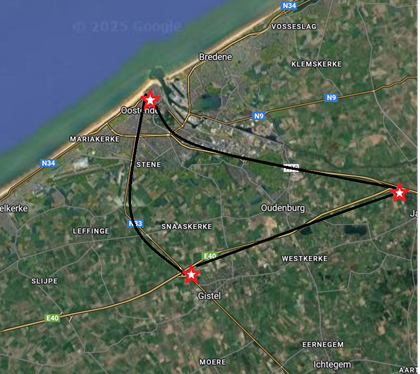 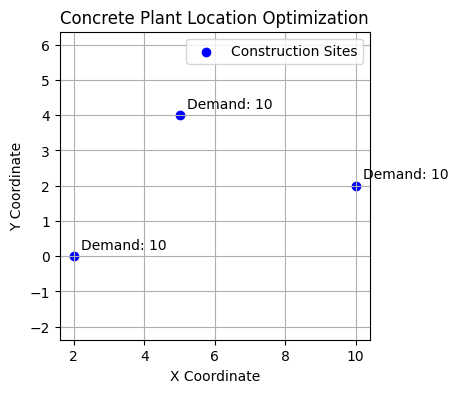

In [ ]:

# 📦 Import necessary packages
import numpy as np
from scipy.optimize import minimize



## 📍 Step 1: Define Construction Site Locations and Demands

We assume three construction sites, each with a coordinate and a demand for concrete.


In [ ]:

# Construction site coordinates (x, y) and demand values
locations = np.array([
    [2, 0],    # Site A
    [5, 4],    # Site B
    [10, 2]     # Site C
])
demands = np.array([10, 10, 10])


## 📉 Step 2: Define the Objective Function

This function calculates the total transportation cost for any candidate location `(x, y)`.
It uses the Euclidean distance from the plant to each site, multiplied by the demand.


In [ ]:

def total_cost(point):
    x, y = point
    distances = np.sqrt((x - locations[:, 0])**2 + (y - locations[:, 1])**2)
    
    return np.sum(distances * demands)



## 🎯 Step 3: Initial Guess

We start the optimization from the demand-weighted average of all site coordinates.


In [ ]:

# Initial guess: demand-weighted centroid
init_guess = np.average(locations, axis=0, weights=demands)
print(f"Initial guess: {init_guess}")



## 🔍 Step 4: Run the Optimization

We use the Powell method (gradient-free) to find the point that minimizes total transportation cost.


In [ ]:

result = minimize(total_cost, init_guess, method='Powell')  # You can try 'CG' or 'Nelder-Mead' as well
print(dir(result))


## ✅ Step 5: Display the Result


In [ ]:

opt_x, opt_y = result.x
print(f"📌 Optimal plant location: ({opt_x:.2f}, {opt_y:.2f})")
print(f"💰 Minimum total transportation cost: {result.fun:.2f}")



## 📈 Visualize the Solution

We can optionally visualize the construction sites and the optimal plant location.


In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
plt.scatter(locations[:, 0], locations[:, 1], c='blue', label='Construction Sites')
# plt.plot(locations[:, 0], locations[:, 1],'r')
# plt.plot(locations[:, 0][::2],locations[:, 1][::2],'r')
plt.scatter(opt_x, opt_y, c='red', marker='X', s=100, label='Optimal Plant')
for i, (x, y) in enumerate(locations):
    plt.text(x+0.2, y+0.2, f"Demand: {demands[i]}")
plt.legend()
plt.grid(True)
plt.title("Concrete Plant Location Optimization")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.axis('equal')
plt.show()


##  Further

We should build the plant located near the road.

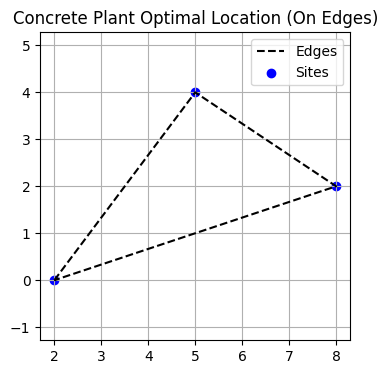

In [ ]:
from scipy.optimize import minimize_scalar
import numpy as np
import matplotlib.pyplot as plt

# Project site coordinates and demands
locations = np.array([
    [2, 0],    # A
    [5, 4],    # B
    [8, 2]     # C
])
demands = np.array([10, 14, 16])

### Average transport cost
It should be lower as transport distance increases.

In [ ]:
plt.figure(figsize=(4,4))
lambd = 2
d = np.linspace(1,100)
c = np.exp(-lambd * d) # cost curve
plt.plot(d,c)
plt.xlabel("dis(km)")
plt.ylabel("average cost(euro)")


In [ ]:
# Cost function along an edge
def edge_cost(t, i, j): 
    k = 3-i-j
    p1 = locations[i]
    p2 = locations[j]
    p3 = locations[k]
    lambd = 2
    point = (1 - t) * p1 + t * p2
    d1 = np.linalg.norm(point - p1)
    d2 = np.linalg.norm(point - p2)
    d31 = d1 + np.linalg.norm(p1 - p3) 
    d32 = d2 + np.linalg.norm(p2 - p3) 
    d3 = min(d31,d32)
    cost_per_km_1 = np.exp(-lambd * d1)
    cost_per_km_2 = np.exp(-lambd * d2) 
    cost_per_km_3 = np.exp(-lambd * d3)
    
    cost = d1*demands[i]*cost_per_km_1+d2*demands[j]*cost_per_km_2 + d3*demands[k]*cost_per_km_3
    return cost

In [ ]:

# List of edges (by indices)
edges = [(0,1), (1,2), (2,0)]

best_cost = float('inf')
best_point = None
edge_results = []

for i, j in edges:
    p1 = locations[i]
    p2 = locations[j]
    result = minimize_scalar(edge_cost, bounds=(0, 1), args=(i, j), method='bounded')
    t_opt = result.x
    
    point_opt = (1 - t_opt) * p1 + t_opt * p2
    edge_results.append((point_opt, result.fun))
    if result.fun < best_cost:
        best_cost = result.fun
        best_point = point_opt
print(f"📌 Optimal point on edge: ({best_point[0]:.2f}, {best_point[1]:.2f})")
print(f"💰 Minimum total transportation cost: {best_cost:.2f}")


In [ ]:
# Optional: Visualization
plt.figure(figsize=(4,4))
plt.plot(*locations[[0,1,2,0]].T, 'k--', label="Edges")
plt.scatter(locations[:,0], locations[:,1], c='blue', label='Sites')
plt.scatter(*best_point, c='red', marker='X', s=100, label='Optimal on edge')
plt.legend()
plt.title("Concrete Plant Optimal Location (On Edges)")
plt.grid(True)
plt.axis('equal')
plt.show()